<a href="https://colab.research.google.com/github/norrismeg/odw/blob/main/Data_Challenge_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Challenge 4 (8 points) -- Advanced**

Use the data file challenge3.gwf with channels H1:CHALLENGE3 and L1:CHALLENGE3.

These are real LIGO data from O2, though we've adjusted the time labels and added some simulated signals.

Any simulated signals have been added to both the H1 and L1 data

All simulated signals have spin = 0 and m1 = m2, with m1 somewhere in the range 10-50 solar masses
1. Identify as many signals as you can. Watch out! These are real data, and so glitches may be present. Any correct detection is +1 point but any false alarms will count -1 point against your score. For each signal you find, list:

  * The merger time
  * The SNR
  * Your estimate of the component masses

2. Identify as many glitches as you can. Make a spectrogram of each one.

3. For each simulated BBH you found, use bilby to compute a posterior distribution for the mass. You can fix the spin and mass ratio to make this run faster.

In [1]:
# Those 2 lines are just to avoid some harmless warnings when importing packages
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

In [2]:
! pip install -q lalsuite
! pip install -q gwpy
! pip install -q pycbc
! pip install -U -q bilby==2.4.0 matplotlib==3.10.0 dynesty==2.1.5 corner==2.2.3 gwpy==3.0.12 lalsuite==7.25 scipy==1.12.0
# -- Click "restart runtime" in the runtime menu

In [3]:
# -- download data
! wget https://dcc.ligo.org/public/0187/G2300818/001/challenge3.gwf

# -- for gwpy
from gwpy.timeseries import TimeSeries,TimeSeriesDict
#gwpy_strain = TimeSeriesDict.read('challenge3.gwf', ["H1:CHALLENGE3","L1:CHALLENGE3"])
#gwpy_strain_L1 = TimeSeries.read('challenge3.gwf', channel="L1:CHALLENGE3")

# -- for pycbc
from pycbc import frame
#pycbc_strain = frame.read_frame('challenge3.gwf', ['H1:CHALLENGE3','L1:CHALLENGE3'])
#pycbc_strain_L1 = frame.read_frame('challenge3.gwf', 'L1:CHALLENGE3')

import bilby

# Make bilby more terse
bilby.core.utils.log.setup_logger(log_level='WARNING')

--2025-06-04 19:11:10--  https://dcc.ligo.org/public/0187/G2300818/001/challenge3.gwf
Resolving dcc.ligo.org (dcc.ligo.org)... 131.215.125.133
Connecting to dcc.ligo.org (dcc.ligo.org)|131.215.125.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 256814830 (245M)
Saving to: ‘challenge3.gwf.1’

challenge3.gwf.1    100%[===================>] 244.92M  91.3MB/s    in 2.7s    

2025-06-04 19:11:13 (91.3 MB/s) - ‘challenge3.gwf.1’ saved [256814830/256814830]



1. Identify as many signals as you can. Watch out! These are real data, and so glitches may be present. Any correct detection is +1 point but any false alarms will count -1 point against your score. For each signal you find, list:

  * The merger time
  * The SNR
  * Your estimate of the component masses

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pycbc.waveform import get_td_waveform
from pycbc.filter import matched_filter, resample_to_delta_t, highpass
from pycbc.psd import interpolate, inverse_spectrum_truncation

False
False


/usr/local/lib/python3.11/dist-packages/gwpy/plot/axes.py:194: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  super().draw(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/gwpy/plot/axes.py:194: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  super().draw(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/gwpy/plot/axes.py:194: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  super().draw(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/gwpy/plot/axes.py:194: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  super().draw(*args, **kwargs)


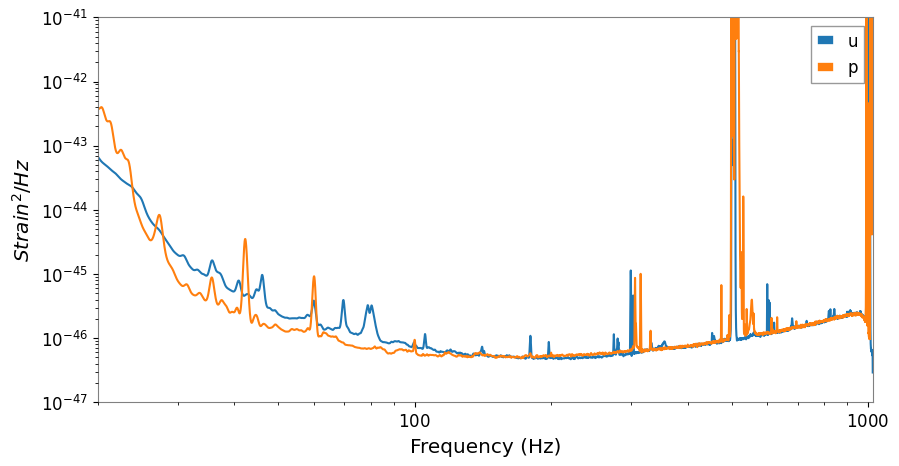

In [5]:
ifos = ['H1','L1']
pycbc_strain = {}
data = {}
psd = {}

plt.figure(figsize=[10, 5])


for ifo in ifos:
    # Read in and precondition the data
    channel = (ifo)+':CHALLENGE3'
    pycbc_strain[ifo] = frame.read_frame('challenge3.gwf', channel)

for ifo, ts in pycbc_strain.items():
    print(isinstance(ts,TimeSeries))
    t_s = highpass(ts, 15)
    data[ifo] = resample_to_delta_t(t_s, 1.0/2048).crop(2, 2)

    # Estimate the power spectral density of the data
    # This chooses to use 2s samples in the PSD estimate.
    p = data[ifo].psd(2)
    p = interpolate(p, data[ifo].delta_f)
    p = inverse_spectrum_truncation(p, int(2 * data[ifo].sample_rate), low_frequency_cutoff=15.0)
    psd[ifo] = p

    plt.plot(psd[ifo].sample_frequencies, psd[ifo], label=ifo)

plt.yscale('log')
plt.xscale('log')
plt.ylim(1e-47, 1e-41)
plt.xlim(20, 1024)
plt.ylabel('$Strain^2 / Hz$')
plt.xlabel('Frequency (Hz)')
plt.grid()
plt.legend('upper left')
plt.show()

In [6]:
m_range = [m for m in range(10,13)]
data_length = len(data['H1'])
print(data_length)

signals = [] # List of possible signals
glitches = [] # List of likely glitches

print(m_range)

threshold = 10 #snr threshold

for mass in m_range:
  hp, hc = get_td_waveform(approximant="SEOBNRv4_opt",
                            mass1=mass,
                            mass2=mass,
                            delta_t=data['H1'].delta_t,
                            f_lower=15)
  hp.resize(len(data['H1']))
  template = hp.cyclic_time_shift(hp.start_time)
  peaks_H1 = []
  peaks_L1 = []

  for ifo, conditioned in data.items():
    snr = matched_filter(template, conditioned, psd=psd[ifo], low_frequency_cutoff=15.0)
    snr = snr.crop(4 + 4, 4)
    for i in range(len(snr)/2048):
      snr_seg = snr[2048*i:2048*(i+1)]
      time_seg = snr.sample_times[2048*i:2048*(i+1)]
      peak = abs(snr_seg).numpy().argmax()
      snrp = snr[peak]
      time = time_seg[peak]
      if abs(snrp) > threshold:
        if ifo = 'H1':
          peaks_H1.append([mass, time, abs(snrp)])
        if ifo = 'L1':
          peaks_L1.append([mass, time, abs(snrp)])
        else print(error)

  print(peaks)

    #peak = abs(snr).numpy().argmax()
    #snrp = snr[peak]
    #time = snr.sample_times[peak]

  # If SNR > threshold (10?) and signal occurs in both detectors within 50 ms using the same template, add time, snrp, and template mass to the list of signals
  # If SNR > threshold (10?) and signal only occurs in one detector, add time, snrp, detector, and template mass to the list of glitches

  #print("Mass: {}. We found a signal at {}s with SNR {}".format(mass, time, abs(snrp)))

8380416
[10, 11, 12]
[['H1', 10, 17.301385080619507, 11.70162065789829], ['H1', 10, 15.772175285593773, 17.960827470276882], ['H1', 10, 10.90627609182106, 24.219049125158204], ['H1', 10, 2.048864328301422, 28.724497825626724], ['H1', 10, -8.864659368955452, 26.851884810966933], ['H1', 10, -15.46774898480623, 20.41894599167321], ['H1', 10, -18.545628740064103, 13.742368175295436], ['H1', 10, 3.5086456736217357, 10.022912904973763], ['H1', 10, 0.17299477912414382, 10.006536279838402], ['L1', 10, 3.4097440519952738, 13.260722529998132], ['L1', 10, 1.1633556300445196, 18.682423023636634], ['L1', 10, -9.145414194853839, 13.695814336924805], ['L1', 10, -5.1155029668405785, 18.28251841908247], ['L1', 10, -15.536903322168232, 29.088631433295834], ['L1', 10, 10.608990821130085, 18.681440237272614], ['L1', 10, 7.501069369268084, 12.00291353305036], ['L1', 10, 10.0193009407945, 21.15824325178956], ['L1', 10, -5.926593426063754, 16.049787433534316], ['L1', 10, 6.173784946385407, 15.438201122574544

In [7]:
print(peaks)

[['H1', 12, 5.93267115506398, 10.153335997600355], ['H1', 12, -2.344660617606171, 11.645220710175591], ['H1', 12, -2.445623995777102, 10.844120428435243], ['H1', 12, 1.5348201285889331, 10.843631717355349], ['H1', 12, 3.3775124903122338, 10.059762894035243], ['H1', 12, -0.8436522855071229, 10.113472610937253], ['H1', 12, 6.76914572823493, 10.357683395496425], ['H1', 12, -2.148524679080168, 13.32471870165643], ['H1', 12, -2.94630504574084, 10.141680141450397], ['H1', 12, -1.8588875386321857, 10.396312303552348], ['H1', 12, 1.8918137462146558, 10.427677509778096], ['H1', 12, 1.8502521837533106, 10.9476104610177], ['H1', 12, -1.9725748538792278, 10.894945680281701], ['L1', 12, 7.8817006154036635, 12.880655040244974], ['L1', 12, -7.637421390231935, 10.85816434273713], ['L1', 12, 7.3565590876644125, 18.817650233302313], ['L1', 12, -18.973624545163084, 14.199473097068308], ['L1', 12, -15.517338043338857, 14.431136318564864], ['L1', 12, 3.4533751486496516, 19.218302741847193], ['L1', 12, -28.

2. Identify as many glitches as you can. Make a spectrogram of each one.

3. For each simulated BBH you found, use bilby to compute a posterior distribution for the mass. You can fix the spin and mass ratio to make this run faster.

In [8]:
sampling_rate = 2048  # needs to be high enough for the signals found in steps above
duration = 8  # needs to be long enough for the signals found in steps above
start_time = 100  # needs to be set so that the segment defined by [start_time,start_time+duration] contains the signal

interferometers = bilby.gw.detector.InterferometerList([])
for ifo_name in ['H1', 'L1']:
    ifo = bilby.gw.detector.get_empty_interferometer(ifo_name)
    ifo.set_strain_data_from_frame_file('challenge3.gwf', sampling_rate, duration, start_time=start_time, channel=f'{ifo_name}:CHALLENGE3')
    interferometers.append(ifo)

In [9]:
print(interferometers)

[Interferometer(name='H1', power_spectral_density=PowerSpectralDensity(psd_file='None', asd_file='/usr/local/lib/python3.11/dist-packages/bilby/gw/detector/noise_curves/aLIGO_O4_high_asd.txt'), minimum_frequency=20.0, maximum_frequency=1024.0, length=4.0, latitude=46.45514666666667, longitude=-119.4076571388889, elevation=142.554, xarm_azimuth=125.9994, yarm_azimuth=215.9994, xarm_tilt=-0.0006195, yarm_tilt=1.25e-05), Interferometer(name='L1', power_spectral_density=PowerSpectralDensity(psd_file='None', asd_file='/usr/local/lib/python3.11/dist-packages/bilby/gw/detector/noise_curves/aLIGO_O4_high_asd.txt'), minimum_frequency=20.0, maximum_frequency=1024.0, length=4.0, latitude=30.562894333333332, longitude=-90.77424038888887, elevation=-6.574, xarm_azimuth=197.7165, yarm_azimuth=287.7165, xarm_tilt=-0.0003121, yarm_tilt=-0.0006107)]


In [10]:
chirp_mass_min = 10/(2**(1/5))
chirp_mass_max = 50/(2**(1/5))
print(chirp_mass_min,chirp_mass_max)

8.705505632961241 43.527528164806206


In [11]:
chirp_mass_min = 10/(2**(1/5))
chirp_mass_max = 50/(2**(1/5))
print(chirp_mass_min,chirp_mass_max)

prior = bilby.core.prior.PriorDict()
prior['chirp_mass'] = Uniform(name='chirp_mass', minimum=chirp_mass_min,maximum=chirp_mass_max)
prior['mass_ratio'] = 1.0
prior['phase'] = Uniform(name="phase", minimum=0, maximum=2*np.pi)
prior['geocent_time'] = Uniform(name="geocent_time", minimum=time_of_event-0.1, maximum=time_of_event+0.1)
prior['a_1'] =  0.0
prior['a_2'] =  0.0
prior['tilt_1'] =  0.0
prior['tilt_2'] =  0.0
prior['phi_12'] =  0.0
prior['phi_jl'] =  0.0
#prior['dec'] =  -1.2232
#prior['ra'] =  2.19432
#prior['theta_jn'] =  1.89694
#prior['psi'] =  0.532268
prior['luminosity_distance'] = PowerLaw(alpha=2, name='luminosity_distance', minimum=50, maximum=2000, unit='Mpc', latex_label='$d_L$')


8.705505632961241 43.527528164806206


NameError: name 'Uniform' is not defined